# Signals in the Noise — Rail Cargo Austria freight forecasting
**Production notebook** for the master's thesis. Reproduces the full pipeline with the standard
libraries: data consolidation, EDA, six forecasting models (seasonal-naive, ETS, SARIMA, SARIMAX,
Prophet, XGBoost) plus an LSTM for mineral oil, a 24-month back-test, and the two design
experiments (weekly-vs-monthly and history length).

### Requirements
```bash
pip install pandas numpy matplotlib statsmodels prophet xgboost scikit-learn holidays torch openpyxl
```
### Configuration
Set `PROJECT` to the folder that contains `Data/` (the commodity CSVs) and the unzipped OneDrive
extract `AbfragePredictions_2011_202604.csv`. Run the cells top to bottom.

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")
import holidays as hol_lib

# ---- CONFIG: point this at your thesis project folder ----
PROJECT  = os.path.expanduser("~/Documents/EMBA/MasterThesis")
DATA_DIR = os.path.join(PROJECT, "Data")
# path to the unzipped operational extract (from OneDrive_1_07-06-2026.zip)
EXTRACT  = os.path.join(DATA_DIR, "AbfragePredictions_2011_202604.csv")
HOLD     = 24            # months held out for back-testing
SEASON_M = 12
COMS = ["buildingmaterials","chemicals","energy","moil","paper","steel","wood"]
print("config set")

config set


## 1  Data consolidation
Combines the curated 2005–2024 commodity CSVs (thousand tonne-km) with the operational extract that
runs to April 2026 (raw tonne-km, German decimal comma). The two sources agree to within a fraction
of a percent once the operational extract is divided by 1,000. The seven commodities are defined by
mutually exclusive NHM code sets, which are reused to extend each series consistently.

In [7]:
import csv, glob
from collections import defaultdict

def build_panels():
    nhm2com, rows = {}, []
    for f in glob.glob(os.path.join(DATA_DIR, "*_2005_2024.csv")):
        com = os.path.basename(f).split("_2005")[0]
        d = pd.read_csv(f)
        for n in d.NHM.unique(): nhm2com[int(n)] = com
        d["commodity"] = com
        rows.append(d[["VJA","VMO","VKW","commodity","TTOKM"]])
    clean = pd.concat(rows)                       # 2005-2024, thousand tonne-km

    agg = defaultdict(float)                       # extend 2025-2026/04 from extract
    if os.path.exists(EXTRACT):
        with open(EXTRACT) as fh:
            r = csv.reader(fh); next(r)
            for row in r:
                if len(row) < 7 or not row[4].isdigit(): continue
                com = nhm2com.get(int(row[4]))
                if com is None: continue
                vja, vmo, vkw = int(row[0]), int(row[1]), int(row[2])
                if vja < 2025 or (vja == 2026 and vmo > 4): continue
                agg[(vja,vmo,vkw,com)] += float(".".join(row[6:]))/1000.0
    ext = pd.DataFrame([(k[0],k[1],k[2],k[3],v) for k,v in agg.items()],
                       columns=["VJA","VMO","VKW","commodity","TTOKM"])
    full = pd.concat([clean, ext], ignore_index=True)

    mon = full.groupby(["commodity","VJA","VMO"])["TTOKM"].sum().reset_index()
    mon["date"] = pd.to_datetime(dict(year=mon.VJA, month=mon.VMO, day=1))
    wk = full.groupby(["commodity","VJA","VKW"])["TTOKM"].sum().reset_index()
    def iso(y,w):
        try: return pd.Timestamp.fromisocalendar(int(y), min(int(w),52), 1)
        except: return pd.NaT
    wk["date"] = [iso(y,w) for y,w in zip(wk.VJA, wk.VKW)]
    wk = wk.dropna(subset=["date"])
    return mon.sort_values(["commodity","date"]), wk.sort_values(["commodity","date"])

monthly, weekly = build_panels()

def series(c, panel="m"):
    df = monthly if panel=="m" else weekly
    if c == "TOTAL":
        s = df.groupby("date")["TTOKM"].sum()
    else:
        s = df[df.commodity==c].set_index("date")["TTOKM"]
    s = s[~s.index.duplicated()].sort_index()
    return s.asfreq("MS") if panel=="m" else s

print("monthly obs per commodity:", monthly.groupby("commodity").size().to_dict())
print("range:", monthly.date.min().date(), "->", monthly.date.max().date())

monthly obs per commodity: {'buildingmaterials': 240, 'chemicals': 240, 'energy': 240, 'moil': 240, 'paper': 240, 'steel': 240, 'wood': 240}
range: 2005-01-01 -> 2024-12-01


## 2  Calendar features (Austrian holidays)

In [8]:
def calendar_features(idx):
    at = hol_lib.Austria()
    holcount, workdays = [], []
    for ts in idx:
        days = pd.date_range(ts, ts + pd.offsets.MonthEnd(0), freq="D")
        h = sum(1 for d in days if d in at)
        holcount.append(h)
        workdays.append(sum(1 for d in days if d.weekday()<5 and d not in at))
    return pd.DataFrame({"holidays":holcount,"workdays":workdays}, index=idx)
calendar_features(series("TOTAL").index[:3])

,holidays,workdays
date,,
2005-01-01,2,20
2005-02-01,0,20
2005-03-01,1,22


## 3  Exploratory data analysis

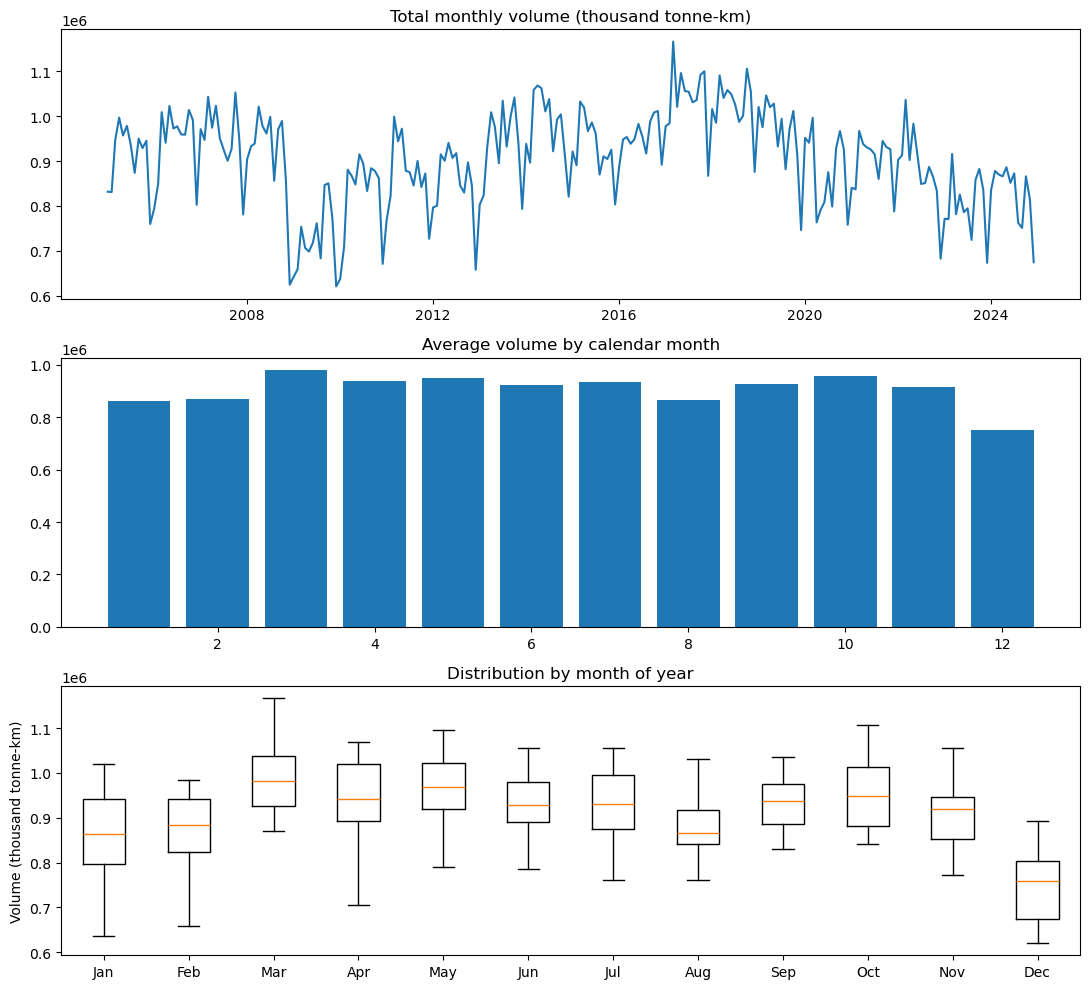

In [14]:
s = series("TOTAL").dropna()
fig, ax = plt.subplots(3,1, figsize=(11,10), sharex=False)
ax[0].plot(s.index, s.values); ax[0].set_title("Total monthly volume (thousand tonne-km)")
by = s.groupby(s.index.month).mean()
ax[1].bar(range(1,13), by.values); ax[1].set_title("Average volume by calendar month")
month_values = [s[s.index.month == m].values for m in range(1, 13)]
ax[2].boxplot(month_values, labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], showfliers=False)
ax[2].set_title("Distribution by month of year")
ax[2].set_ylabel("Volume (thousand tonne-km)")
plt.tight_layout(); plt.show()

## 4  Forecasting models (standard libraries)
Each function trains on a monthly Series and returns a forecast for `h` future months.

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def f_snaive(train, h, fidx, m=SEASON_M):
    v=list(train.values)
    return np.array([v[-m+(i%m)] if i<m else v[-m] for i in range(h)])

def f_ets(train, h, fidx):
    fit = ExponentialSmoothing(train, trend="add", seasonal="add",
                               seasonal_periods=SEASON_M).fit()
    return fit.forecast(h).values

def f_sarima(train, h, fidx, order=(1,1,1), sorder=(1,1,1,12)):
    fit = SARIMAX(train, order=order, seasonal_order=sorder,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return fit.forecast(h).values

def f_sarimax(train, h, fidx, exog_tr=None, exog_f=None, order=(1,1,1), sorder=(1,1,1,12)):
    fit = SARIMAX(train, exog=exog_tr, order=order, seasonal_order=sorder,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return fit.forecast(h, exog=exog_f).values

def f_prophet(train, h, fidx, holidays_df=None):
    from prophet import Prophet
    d = pd.DataFrame({"ds":train.index, "y":train.values})
    mdl = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                  holidays=holidays_df, changepoint_prior_scale=0.05)
    mdl.fit(d)
    fut = pd.DataFrame({"ds":fidx})
    return mdl.predict(fut)["yhat"].values

def f_xgboost(train, h, fidx):
    from xgboost import XGBRegressor
    y = train.values.astype(float); idx = train.index
    def feats(ti, fi, hist):
        return [ti, hist[-1], hist[-2], hist[-3], hist[-12],
                np.mean(hist[-3:]), np.mean(hist[-12:])] + [int(fi.month==k) for k in range(1,13)]
    X, Y = [], []
    for ti in range(15, len(y)):
        X.append(feats(ti, idx[ti], y[:ti])); Y.append(y[ti])
    mdl = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.9)
    mdl.fit(np.array(X), np.array(Y))
    histf = list(y); out=[]
    for i in range(h):
        ti=len(y)+i; row=np.array(feats(ti, fidx[i], np.array(histf))).reshape(1,-1)
        p=float(mdl.predict(row)[0]); out.append(p); histf.append(p)
    return np.array(out)

def austria_holidays_df(years):
    at = hol_lib.Austria(years=years)
    return pd.DataFrame({"holiday":"AT","ds":pd.to_datetime(list(at.keys()))})
print("models defined")

models defined


## 5  Back-test (24-month holdout) and metrics

In [12]:
def mape(a,f): a,f=np.array(a,float),np.array(f,float); return np.mean(np.abs((a-f)/a))*100
def mae(a,f):  return np.mean(np.abs(np.array(a,float)-np.array(f,float)))
def rmse(a,f): return np.sqrt(np.mean((np.array(a,float)-np.array(f,float))**2))

def backtest(c):
    s=series(c).dropna(); tr=s.iloc[:-HOLD]; te=s.iloc[-HOLD:]; fidx=te.index
    cal_tr=calendar_features(tr.index); cal_f=calendar_features(fidx)
    hdf=austria_holidays_df(range(tr.index.year.min(), fidx.year.max()+1))
    fc={
        "SeasonalNaive": f_snaive(tr,HOLD,fidx),
        "ETS":           f_ets(tr,HOLD,fidx),
        "SARIMA":        f_sarima(tr,HOLD,fidx),
        "SARIMAX":       f_sarimax(tr,HOLD,fidx, cal_tr.values, cal_f.values),
        "Prophet":       f_prophet(tr,HOLD,fidx, hdf),
        "XGBoost":       f_xgboost(tr,HOLD,fidx),
    }
    return te, {k: dict(MAPE=mape(te.values,v), MAE=mae(te.values,v), RMSE=rmse(te.values,v))
                for k,v in fc.items()}, fc

results={}
for c in ["TOTAL"]+COMS:
    _,res,_=backtest(c); results[c]=res
    print(c, {k:round(v["MAPE"],1) for k,v in res.items()})
pd.DataFrame({c:{k:results[c][k]["MAPE"] for k in results[c]} for c in results}).T.round(1)

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

## 6  Experiment A — weekly vs monthly training

In [13]:
def weekly_to_monthly_mape(c, test_index):
    s=series(c,"w").dropna(); start=test_index[0]
    tr=s[s.index<start]; tew=s[s.index>=start]
    if len(tew)<20: return np.nan
    # simple seasonal-naive at weekly level (52) then aggregate to month
    v=list(tr.values); pred=[v[-52+(i%52)] if i<52 else v[-52] for i in range(len(tew))]
    dfp=pd.DataFrame({"date":tew.index,"pred":pred,"act":tew.values})
    dfp["m"]=dfp["date"].values.astype("datetime64[M]")
    g=dfp.groupby("m").agg(pred=("pred","sum"),act=("act","sum"))
    return np.mean(np.abs(g.act-g.pred)/g.act)*100

for c in ["TOTAL","steel","moil"]:
    s=series(c).dropna(); te=s.iloc[-HOLD:]
    mm=mape(te.values, f_sarima(s.iloc[:-HOLD],HOLD,te.index))
    wm=weekly_to_monthly_mape(c, te.index)
    print(f"{c:7s} monthly={mm:5.2f}%  weekly->monthly={wm:5.2f}%")

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

## 7  Experiment B — history length (5/10/15/20 years)

In [ ]:
for c in ["TOTAL","steel","moil"]:
    s=series(c).dropna(); te=s.iloc[-HOLD:]; hist=s.iloc[:-HOLD]; row={}
    for yrs in [5,10,15,20]:
        tr=hist.iloc[-yrs*12:]
        row[yrs]=round(mape(te.values, f_sarima(tr,HOLD,te.index)),2)
    print(c, row)

## 8  LSTM spotlight — mineral oil
A small LSTM, included because an earlier RCA project found it best for mineral oil. Requires `torch`.

In [ ]:
def f_lstm(train, h, fidx, lookback=12, epochs=300):
    import torch, torch.nn as nn
    y=train.values.astype("float32"); mu,sd=y.mean(),y.std(); z=(y-mu)/sd
    X=np.array([z[i:i+lookback] for i in range(len(z)-lookback)])
    Y=np.array([z[i+lookback] for i in range(len(z)-lookback)])
    Xt=torch.tensor(X).unsqueeze(-1); Yt=torch.tensor(Y).unsqueeze(-1)
    class Net(nn.Module):
        def __init__(s): super().__init__(); s.l=nn.LSTM(1,32,batch_first=True); s.f=nn.Linear(32,1)
        def forward(s,x): o,_=s.l(x); return s.f(o[:,-1])
    net=Net(); opt=torch.optim.Adam(net.parameters(),lr=0.01); lossf=nn.MSELoss()
    for _ in range(epochs):
        opt.zero_grad(); loss=lossf(net(Xt),Yt); loss.backward(); opt.step()
    seq=list(z[-lookback:]); out=[]
    for _ in range(h):
        xi=torch.tensor(np.array(seq[-lookback:],dtype="float32")).reshape(1,lookback,1)
        p=float(net(xi).item()); out.append(p); seq.append(p)
    return np.array(out)*sd+mu

s=series("moil").dropna(); tr=s.iloc[:-HOLD]; te=s.iloc[-HOLD:]
try:
    fc=f_lstm(tr,HOLD,te.index)
    print("mineral oil LSTM MAPE: %.2f%%" % mape(te.values,fc))
except ImportError:
    print("Install torch to run the LSTM cell.")

## 9  Export results
Saves the metric table for the thesis.

In [ ]:
res_df=pd.DataFrame({c:{k:results[c][k]["MAPE"] for k in results[c]} for c in results}).T.round(2)
res_df.to_csv(os.path.join(PROJECT,"model_metrics_notebook.csv"))
res_df